In [64]:
import pandas as pd
sales = pd.read_csv(r"D:\old dataset\sales_train_validation.csv")
cal = pd.read_csv(r"D:\old dataset\calendar.csv")
sell = pd.read_csv(r"D:\old dataset\sell_prices.csv")


In [ ]:
all = pd.melt(
    sales,
    id_vars=['item_id','store_id','dept_id','cat_id','state_id'],
    var_name='day',
    value_name='sales'
)

# =========================
# 3. MERGE WITH CALENDAR
# =========================

all = all.merge(cal, left_on='day', right_on='d')

# =========================
# 4. CONVERT DATE
# =========================

all['date'] = pd.to_datetime(all['date'])


# =========================
# 5. SORT DATA
# =========================

all = all.sort_values(['item_id','store_id','date'])

# =========================
# 6. SPLIT DATA
# =========================

train= all[all['date'].dt.year < 2016].copy()
test_2016_df = all[all['date'].dt.year == 2016].copy()

# =========================
# 7. SAVE OUTPUT (OPTIONAL)
# =========================

train.to_csv("data/train_before_2016.csv", index=False)
test_2016_df.to_csv("data/test_2016.csv", index=False)

In [ ]:
train =pd.read_csv("D:\old dataset\\train test\\train.csv")

In [66]:
def reduce_mem(train):
    for col in train.columns:
        if train[col].dtype == 'int64':
            train[col] = train[col].astype('int32')
        elif train[col].dtype == 'float64':
            train[col] = train[col].astype('float32')
    return train

df = reduce_mem(train)

In [67]:
train['day'] = train['day'].str.replace('d_', '', regex=False)
train['day'] = train['day'].astype('int32')

In [68]:
train = train[train['day'] > 1100]

In [69]:
train.drop(columns=['d'], inplace=True)

In [70]:
price_map = sell.set_index(['store_id','item_id','wm_yr_wk'])['sell_price']

train['sell_price'] = train.set_index(['store_id','item_id','wm_yr_wk']).index.map(price_map)

In [71]:
train.head()

,item_id,store_id,dept_id,cat_id,state_id,day,sales,date,wm_yr_wk,weekday,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
3355518,FOODS_1_003,CA_4,FOODS_1,FOODS,CA,1101,0,2014-02-02,11401,Sunday,...,2,2014,SuperBowl,Sporting,NaN,NaN,1,0,1,2.88
3358567,FOODS_1_003,CA_4,FOODS_1,FOODS,CA,1102,0,2014-02-03,11401,Monday,...,2,2014,NaN,NaN,NaN,NaN,1,1,1,2.88
3361616,FOODS_1_003,CA_4,FOODS_1,FOODS,CA,1103,0,2014-02-04,11401,Tuesday,...,2,2014,NaN,NaN,NaN,NaN,1,0,0,2.88
3364665,FOODS_1_003,CA_4,FOODS_1,FOODS,CA,1104,0,2014-02-05,11401,Wednesday,...,2,2014,NaN,NaN,NaN,NaN,1,1,1,2.88
3367714,FOODS_1_003,CA_4,FOODS_1,FOODS,CA,1105,1,2014-02-06,11401,Thursday,...,2,2014,NaN,NaN,NaN,NaN,1,1,1,2.88


In [72]:
train.to_csv('train.csv')


<Axes: xlabel='month'>

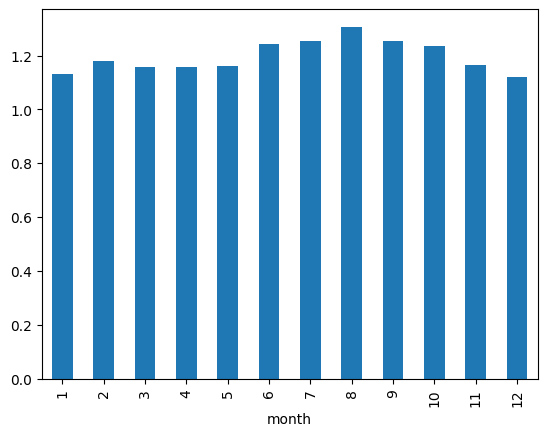

In [73]:
train.groupby('month')['sales'].mean().plot(kind='bar')

<Axes: xlabel='store_id'>

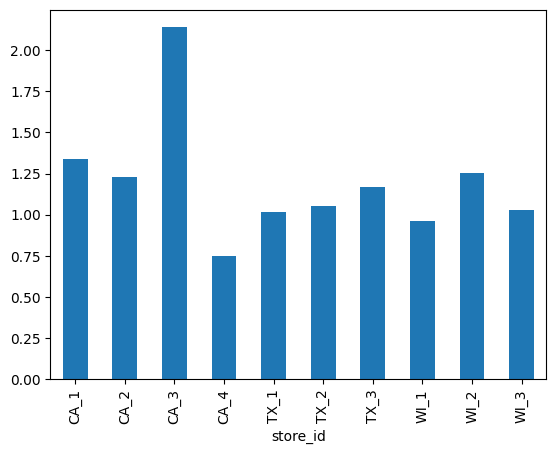

In [74]:
train.groupby('store_id')['sales'].mean().plot(kind='bar')

<Axes: xlabel='weekday'>

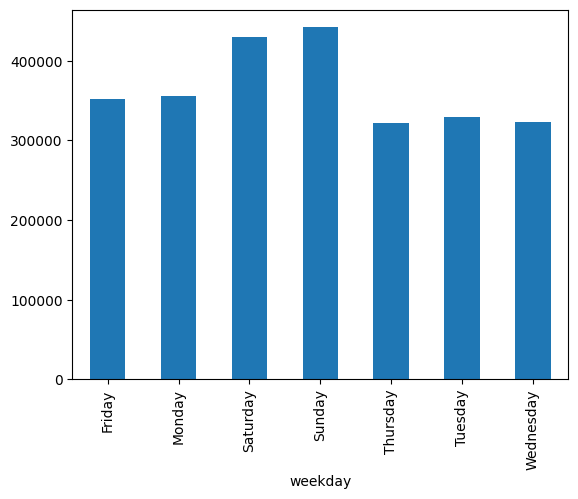

In [75]:
train.groupby('weekday')['sales'].sum().plot(kind='bar')

<Axes: xlabel='store_id'>

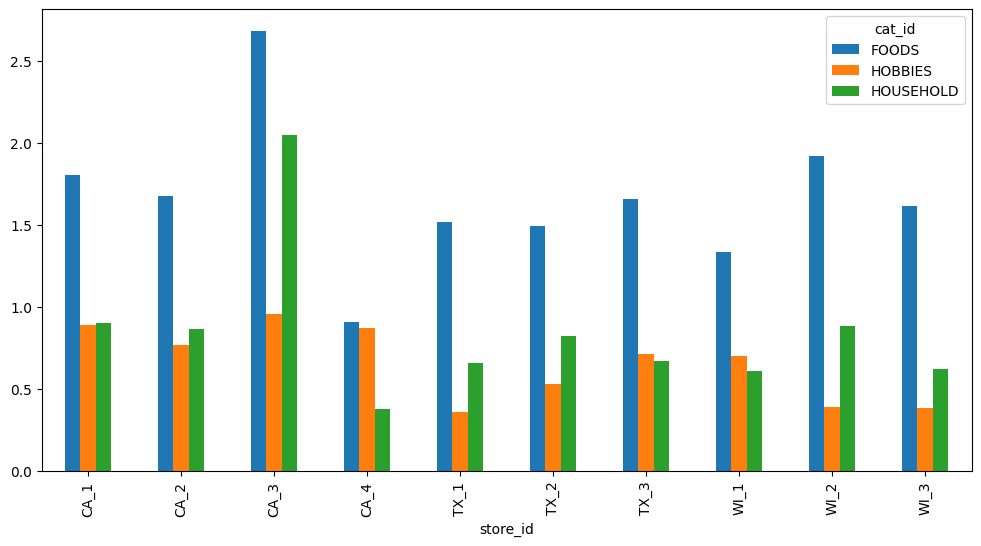

In [76]:
train.groupby(['store_id','cat_id'])['sales'].mean().unstack().plot(kind='bar', figsize=(12,6))

In [77]:
# 1. Sorting
train = train.sort_values(['item_id','store_id','date'])

# 2. Time Features
train['dayofweek'] = train['date'].dt.dayofweek
train['week'] = train['date'].dt.isocalendar().week.astype(int)

# 3. Lag Features
train['lag_1'] = train.groupby(['item_id','store_id'])['sales'].shift(1)
train['lag_7'] = train.groupby(['item_id','store_id'])['sales'].shift(7)


# 4. Rolling Features
train['rolling_mean_7'] = train.groupby(['item_id','store_id'])['sales'].transform(
    lambda x: x.shift(1).rolling(7).mean()
)


# 5. Remove missing values 
train = train.dropna(subset=['lag_7'])

# 6. Encoding
from sklearn.preprocessing import LabelEncoder

for col in ['item_id','store_id','dept_id','cat_id','state_id']:
    train[col] = LabelEncoder().fit_transform(train[col])

print(train.shape)
print(train.head())

print(train['sales'].describe())

print("Unique items:", train['item_id'].nunique())

print(train['item_id'].value_counts().head(10))

print("Zero ratio:", (train['sales'] == 0).mean())





(2106859, 26)
         item_id  store_id  dept_id  cat_id  state_id   day sales       date  \
3376861        0         3        0       0         0  1108     0 2014-02-09   
3379910        0         3        0       0         0  1109     0 2014-02-10   
3382959        0         3        0       0         0  1110     0 2014-02-11   
3386008        0         3        0       0         0  1111     1 2014-02-12   
3389057        0         3        0       0         0  1112     0 2014-02-13   

         wm_yr_wk    weekday  ...  event_type_2  snap_CA  snap_TX snap_WI  \
3376861     11402     Sunday  ...           NaN        1        1       1   
3379910     11402     Monday  ...           NaN        1        0       0   
3382959     11402    Tuesday  ...           NaN        0        1       1   
3386008     11402  Wednesday  ...           NaN        0        1       1   
3389057     11402   Thursday  ...           NaN        0        1       0   

        sell_price dayofweek week  lag_1  